# Maternal Health Risk Prediction Using Ensemble Machine Learning

## Project Overview

This project develops an end-to-end machine learning pipeline to predict maternal-health risk levels as **low risk**, **mid risk**, or **high risk**. The objective is to demonstrate how machine learning can support triage and prioritisation in under-resourced healthcare settings.

The project includes:

- Data auditing, cleaning, and exploratory data analysis
- Domain-informed feature engineering
- Leakage-safe preprocessing and reproducible train/validation/test splitting
- Logistic Regression baseline modelling
- Random Forest bagging, AdaBoost boosting, and soft Voting ensemble models
- Cross-validation and hyperparameter tuning
- Final evaluation using Macro-F1, precision, recall, ROC-AUC, and confusion matrices
- Global permutation importance and local LIME explainability
- Fairness, ethics, privacy, and deployment-limitations discussion

## Important Scope Statement

This system is a **decision-support and triage tool only**. It does not provide diagnosis, treatment advice, or replace qualified healthcare professionals.

In [108]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier, StackingClassifier
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score
)
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from lime.lime_tabular import LimeTabularExplainer

In [67]:
df = pd.read_csv("Maternal Health Risk Data Set.csv")

In [68]:
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [69]:
df.shape

(1014, 7)

In [70]:
df.dtypes

Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel          str
dtype: object

In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   str    
dtypes: float64(2), int64(4), str(1)
memory usage: 63.8 KB


In [72]:
df.isnull().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

In [73]:
df.duplicated().sum()

np.int64(562)

In [74]:
df["RiskLevel"].value_counts()

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

In [75]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


There are 562 duplicate values and a minimum heart rate of 7 is too low and is considered an outlier.

In [76]:
df = df.drop_duplicates().reset_index(drop = True) # dropping the duplicate rows

In [77]:
df.duplicated().sum()

np.int64(0)

In [78]:
df = df[df["HeartRate"] >= 30].reset_index(drop = True)

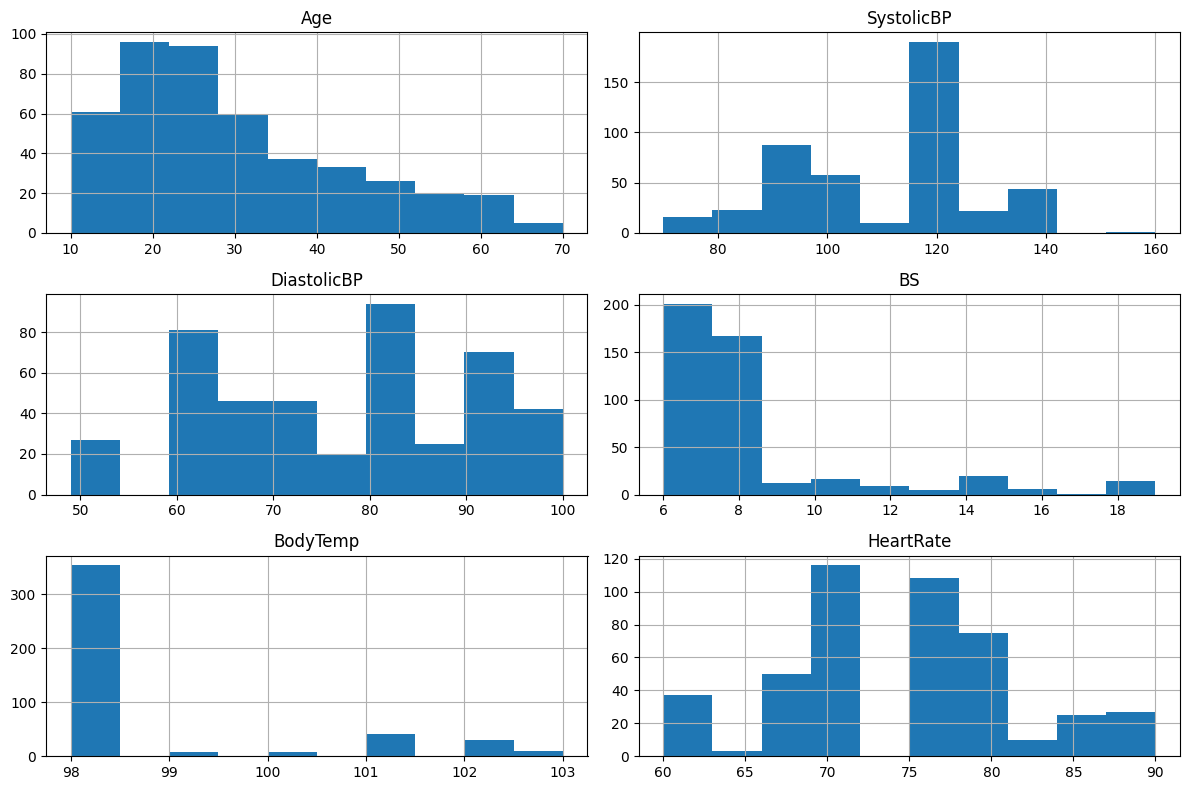

In [79]:
df.hist(figsize = (12, 8))
plt.tight_layout()

Age is more skewed towards younger patients (the teen range), implying they tend to have more pregnancy complications. 

Most women have normal blood sugar (6 - 8), whereas those with really high readings (towards 19) are at risk.

Almost everyone in the dataset is at a normal body temperature, with just a few spikes here and there.

Heart rate is also naturally likely to go up during pregnancy and is not a deciing factor alon for risk. 

<Axes: >

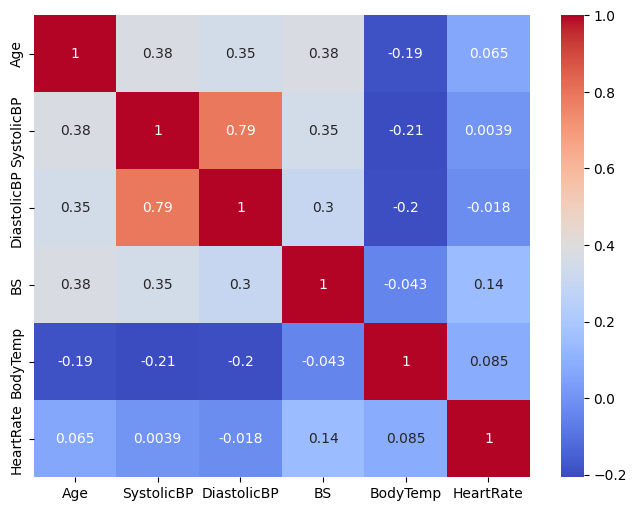

In [80]:
plt.figure(figsize = (8, 6))
sns.heatmap(df.select_dtypes("number").corr(), annot = True, cmap = "coolwarm")

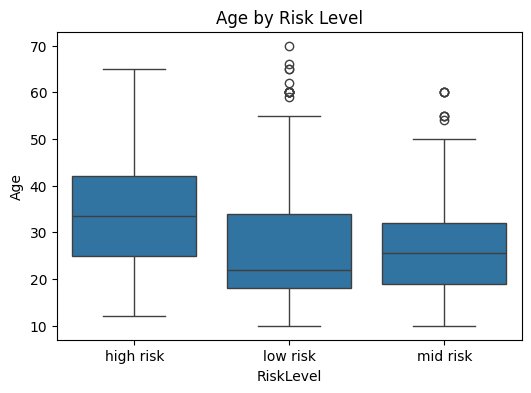

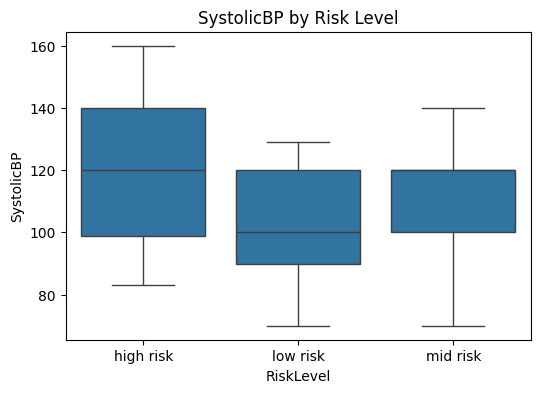

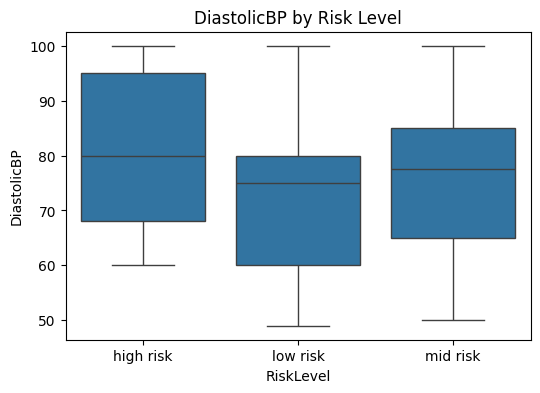

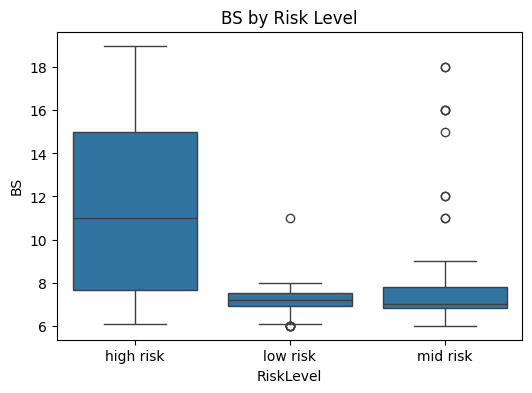

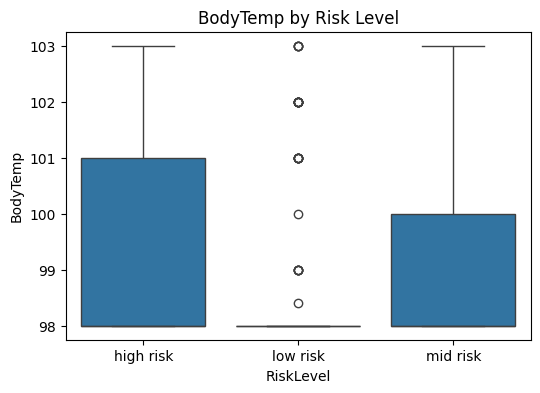

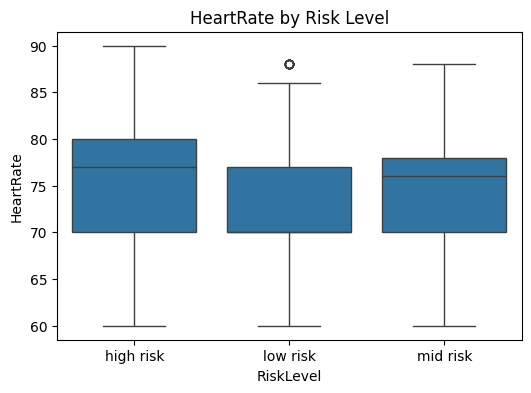

In [81]:
for col in ["Age","SystolicBP","DiastolicBP","BS","BodyTemp","HeartRate"]:
    plt.figure(figsize = (6, 4))
    sns.boxplot(data = df, x = "RiskLevel", y = col)
    plt.title(f"{col} by Risk Level")

High-risk patients have noticeably higher blood sugar (median around 11) compared to low-risk patients (packed around 7), compared to low-risk patients. Mid-risk patients are almost similar to the level of low-risk, with a few exceptional cases.

High-risk patients tend to have higher and more spread out blood pressure readings, while low-risk patients cluster lower and tighter.

When it comes to body temperature, low-risk patients are almost sitting at a normal 98 reading with a few exceptions and mid-risk patients have a much wider spread, with some reaching upto the fever territory (101 - 103). So fever is never seen in low-risk patients.

High-risk patients are those that are slightly older, compared to low/mid-risk patients.

In [82]:
df["Pulse Pressure"] = df["SystolicBP"] - df["DiastolicBP"]  # pulse pressure is the difference b/w systolic and diastolic

In [83]:
df["MAP"] = df["DiastolicBP"] + (df["Pulse Pressure"]/3) # mean arterial pressure is the average pulse pressure in arteries during one cardiac cycle

In [84]:
def age_band(age):
    if age < 18:
        return "teen"
    elif age < 35:
        return "prime"
    else:
        return "advanced"
df["AgeBand"] = df["Age"].apply(age_band)

In [85]:
df["HighBS_flag"] = (df["BS"] >= 7.8).astype(int) # setting threshold flag

In [86]:
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,Pulse Pressure,MAP,AgeBand,HighBS_flag
0,25,130,80,15.0,98.0,86,high risk,50,96.666667,prime,1
1,35,140,90,13.0,98.0,70,high risk,50,106.666667,advanced,1
2,29,90,70,8.0,100.0,80,high risk,20,76.666667,prime,1
3,30,140,85,7.0,98.0,70,high risk,55,103.333333,prime,0
4,35,120,60,6.1,98.0,76,low risk,60,80.000000,advanced,0


In [87]:
X = df.drop(columns = ["RiskLevel"])
y = df["RiskLevel"]

In [88]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size = 0.20, stratify = y, random_state = 42)

In [89]:
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size = 0.25, stratify = y_temp, random_state = 42) # in order to prevent data leakage

In [90]:
print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.value_counts(normalize = True))

(270, 10) (90, 10) (91, 10)
RiskLevel
low risk     0.514815
high risk    0.248148
mid risk     0.237037
Name: proportion, dtype: float64


## Train, Validation, and Test Strategy

The cleaned dataset contains 451 records. It was split reproducibly using `random_state = 42` and stratification by `RiskLevel`:

- Training set: 270 records (60%)
- Validation set: 90 records (20%)
- Test set: 91 records (20%)

Stratification preserves the approximate class distribution across all splits. The test set is kept untouched during preprocessing, tuning, and model selection, and is used only for final model comparison.

In [91]:
numeric_features = ["Age", "SystolicBP", "DiastolicBP", "BS", "BodyTemp", "HeartRate", "Pulse Pressure", "MAP", "HighBS_flag"]
categorical_features = ["AgeBand"]

In [ ]:
numeric_transformer = Pipeline([("imputer", SimpleImputer(strategy = "median")), ("scaler", StandardScaler())])

In [ ]:
categorical_transformer = Pipeline([("imputer", SimpleImputer(strategy = "most_frequent")), ("encoder", OneHotEncoder(drop = "first", handle_unknown = "ignore"))
])

In [ ]:
preprocessor = ColumnTransformer([("num", numeric_transformer, numeric_features), ("cat", categorical_transformer, categorical_features)])

## Leakage-Safe Preprocessing

Numerical variables are median-imputed and standardised, while the categorical `AgeBand` feature is most-frequent-imputed and one-hot encoded. Although this dataset has no missing values, imputers were retained so that the pipeline remains robust for future input records.

Preprocessing is included inside each model pipeline. Therefore, imputation, scaling, and encoding are fitted only on the relevant training data within each cross-validation fold. This prevents information leakage from validation or test data.

In [95]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

## Cross-Validation Strategy

Five-fold stratified cross-validation was used during hyperparameter tuning. Stratification ensures that each fold retains representation from low-, mid-, and high-risk classes. Macro-F1 was used as the tuning metric because the risk classes are not equally represented and each class should contribute equally to model assessment.

In [96]:
log_reg_pipeline = Pipeline([("preprocessor", preprocessor), ("model", LogisticRegression(class_weight = "balanced", max_iter = 1000, random_state = 42))])

log_reg_grid = GridSearchCV(estimator = log_reg_pipeline, param_grid = {"model__C": [0.01, 0.1, 1, 10]}, scoring = "f1_macro", cv = cv, n_jobs = -1)

log_reg_grid.fit(X_train, y_train)

print("Best baseline parameters:", log_reg_grid.best_params_)
print("Best baseline CV macro-F1:", log_reg_grid.best_score_)

Best baseline parameters: {'model__C': 0.1}
Best baseline CV macro-F1: 0.5729032149051936


## Baseline Model: Logistic Regression

Logistic Regression was used as the interpretable baseline model. The best regularisation setting was `C = 0.1`, producing a cross-validation macro-F1 score of 0.573.

This establishes the minimum benchmark that the ensemble models must improve upon.

In [97]:
rf_pipeline = Pipeline([("preprocessor", preprocessor), ("model", RandomForestClassifier(class_weight = "balanced", random_state = 42, n_jobs = -1))])

rf_grid = GridSearchCV(estimator = rf_pipeline, param_grid = {"model__n_estimators": [200, 400], "model__max_depth": [None, 8], "model__min_samples_leaf": [1, 3]}, scoring = "f1_macro", cv = cv, n_jobs = -1)

rf_grid.fit(X_train, y_train)

print("Best Random Forest parameters:", rf_grid.best_params_)
print("Best CV macro-F1:", rf_grid.best_score_)

Best Random Forest parameters: {'model__max_depth': 8, 'model__min_samples_leaf': 3, 'model__n_estimators': 200}
Best CV macro-F1: 0.5863867973943935


## Bagging Model: Random Forest

The tuned Random Forest used 200 trees, a maximum depth of 8, and a minimum of 3 samples per leaf. Its cross-validation macro-F1 score was 0.586, exceeding the Logistic Regression baseline during training cross-validation.

Random Forest was selected as the bagging model because it can capture non-linear relationships and interactions among maternal vital-sign features.

In [98]:
ada_pipeline = Pipeline([("preprocessor", preprocessor), ("model", AdaBoostClassifier(random_state = 42))])

ada_grid = GridSearchCV(estimator = ada_pipeline, param_grid = {"model__n_estimators": [100, 200], "model__learning_rate": [0.05, 0.5, 1.0]}, scoring = "f1_macro", cv = cv, n_jobs = -1)

ada_grid.fit(X_train, y_train)

print("Best AdaBoost parameters:", ada_grid.best_params_)
print("Best CV macro-F1:", ada_grid.best_score_)

Best AdaBoost parameters: {'model__learning_rate': 1.0, 'model__n_estimators': 100}
Best CV macro-F1: 0.5932282528565473


## Boosting Model: AdaBoost

The best AdaBoost configuration used 100 estimators with a learning rate of 1.0. It achieved the strongest cross-validation macro-F1 score of 0.593.

Boosting sequentially focuses on difficult-to-classify observations, which can be useful when risk groups overlap. However, its final performance must still be verified on the untouched test set.

In [ ]:
voting_pipeline = Pipeline([("preprocessor", preprocessor), ("model", VotingClassifier(estimators = [
            (
                "lr",
                LogisticRegression(
                    class_weight = "balanced",
                    max_iter = 2000,
                    random_state = 42
                )
            ),
            (
                "rf",
                RandomForestClassifier(
                    n_estimators = 300,
                    class_weight = "balanced",
                    random_state = 42,
                    n_jobs = 1
                )
            ),
            (
                "ada",
                AdaBoostClassifier(
                    n_estimators = 200,
                    learning_rate = 0.5,
                    random_state = 42
                )
            )
        ],
        voting = "soft",
        n_jobs = 1
    ))
])

voting_grid = GridSearchCV(
    estimator = voting_pipeline,
    param_grid = {
        "model__weights": [
            (1, 1, 1),
            (2, 2, 1),
            (1, 2, 1)
        ]
    },
    scoring = "f1_macro",
    cv = cv,
    n_jobs = -1
)

voting_grid.fit(X_train, y_train)

print("Best Voting parameters:", voting_grid.best_params_)
print("Best Voting CV macro-F1:", voting_grid.best_score_)

Best Voting parameters: {'model__weights': (2, 2, 1)}
Best Voting CV macro-F1: 0.5567524206715462


## Heterogeneous Voting Ensemble

A soft Voting Ensemble combined Logistic Regression, Random Forest, and AdaBoost. The best weights were `(2, 2, 1)`, giving more influence to Logistic Regression and Random Forest.

Its cross-validation macro-F1 score was 0.557. Combining multiple models does not automatically improve performance; the final test comparison determines whether the ensemble generalises better than the baseline.

In [ ]:
tuned_models = {
    "Logistic Regression (Baseline)": log_reg_grid.best_estimator_,
    "Random Forest (Bagging)": rf_grid.best_estimator_,
    "AdaBoost (Boosting)": ada_grid.best_estimator_,
    "Voting Ensemble": voting_grid.best_estimator_
}

validation_rows = []

for name, model in tuned_models.items():
    predictions = model.predict(X_val)

    validation_rows.append({
        "Model": name,
        "Macro F1": f1_score(y_val, predictions, average = "macro"),
        "Macro Precision": precision_score(
            y_val, predictions, average = "macro", zero_division = 0
        ),
        "Macro Recall": recall_score(
            y_val, predictions, average = "macro", zero_division = 0
        )
    })

validation_results = pd.DataFrame(validation_rows).sort_values(by = "Macro F1", ascending = False).reset_index(drop = True)

validation_results

,Model,Macro F1,Macro Precision,Macro Recall
0,AdaBoost (Boosting),0.662751,0.680222,0.660189
1,Logistic Regression (Baseline),0.655298,0.661343,0.658162
2,Random Forest (Bagging),0.654324,0.654798,0.654063
3,Voting Ensemble,0.610751,0.614108,0.611510


## Validation-Set Comparison

On the validation set, AdaBoost achieved the highest macro-F1 score (0.663), followed closely by Logistic Regression (0.655) and Random Forest (0.654). The Voting Ensemble achieved 0.611.

Validation results are used to understand model behaviour before the final test evaluation. The test set remains untouched at this stage.

In [ ]:
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

final_models = {name: clone(model).fit(X_train_val, y_train_val) for name, model in tuned_models.items()}

## Final Model Refit

After tuning was completed, each selected model configuration was refitted using the combined training and validation data. This provides each final model with 80% of the available cleaned data while preserving the 20% test set for one final, unbiased comparison.

In [ ]:
test_rows = []

for name, model in final_models.items():
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)

    test_rows.append({
        "Model": name,
        "Macro F1": f1_score(y_test, predictions, average = "macro"),
        "Macro Precision": precision_score(
            y_test, predictions, average = "macro", zero_division = 0
        ),
        "Macro Recall": recall_score(
            y_test, predictions, average = "macro", zero_division = 0
        ),
        "ROC-AUC (OvR)": roc_auc_score(
            y_test,
            probabilities,
            labels = model.classes_,
            multi_class = "ovr",
            average = "macro"
        )
    })

test_results = pd.DataFrame(test_rows).sort_values(by = "Macro F1", ascending = False).reset_index(drop = True)

test_results

,Model,Macro F1,Macro Precision,Macro Recall,ROC-AUC (OvR)
0,Random Forest (Bagging),0.616898,0.654887,0.603718,0.803147
1,Voting Ensemble,0.615482,0.628758,0.605715,0.767226
2,Logistic Regression (Baseline),0.578874,0.598116,0.569020,0.743871
3,AdaBoost (Boosting),0.569916,0.666529,0.562574,0.793185


## Final Untouched Test-Set Results

Random Forest was the best overall model on the untouched test set:

| Model | Macro-F1 | ROC-AUC |
|---|---:|---:|
| Random Forest | 0.617 | 0.803 |
| Voting Ensemble | 0.615 | 0.767 |
| Logistic Regression baseline | 0.579 | 0.744 |
| AdaBoost | 0.570 | 0.793 |

Random Forest improved macro-F1 by 0.038 and ROC-AUC by 0.059 compared with the Logistic Regression baseline. Therefore, the bagging ensemble outperformed the baseline on the final test set.


Logistic Regression (Baseline)
              precision    recall  f1-score   support

   high risk       0.72      0.57      0.63        23
    low risk       0.70      0.81      0.75        47
    mid risk       0.37      0.33      0.35        21

    accuracy                           0.64        91
   macro avg       0.60      0.57      0.58        91
weighted avg       0.63      0.64      0.63        91



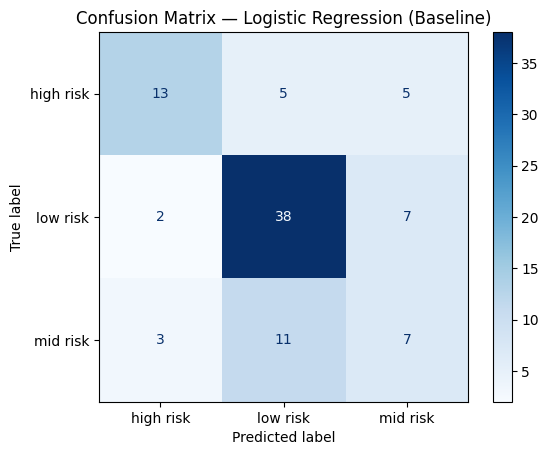


Random Forest (Bagging)
              precision    recall  f1-score   support

   high risk       0.84      0.70      0.76        23
    low risk       0.66      0.83      0.74        47
    mid risk       0.46      0.29      0.35        21

    accuracy                           0.67        91
   macro avg       0.65      0.60      0.62        91
weighted avg       0.66      0.67      0.65        91



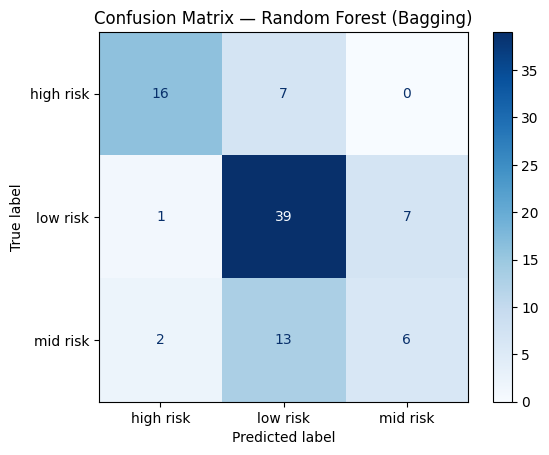


AdaBoost (Boosting)
              precision    recall  f1-score   support

   high risk       0.93      0.61      0.74        23
    low risk       0.64      0.94      0.76        47
    mid risk       0.43      0.14      0.21        21

    accuracy                           0.67        91
   macro avg       0.67      0.56      0.57        91
weighted avg       0.66      0.67      0.63        91



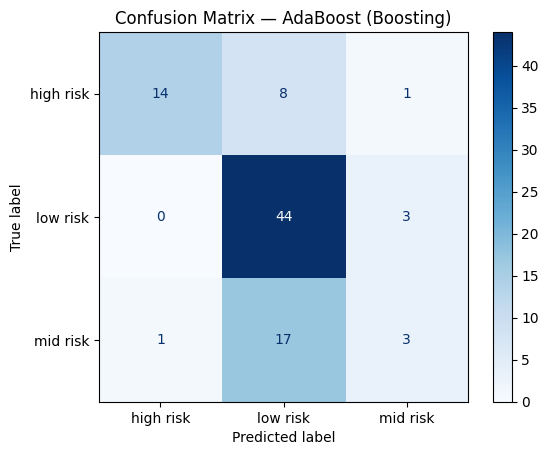


Voting Ensemble
              precision    recall  f1-score   support

   high risk       0.85      0.74      0.79        23
    low risk       0.69      0.74      0.71        47
    mid risk       0.35      0.33      0.34        21

    accuracy                           0.65        91
   macro avg       0.63      0.61      0.62        91
weighted avg       0.65      0.65      0.65        91



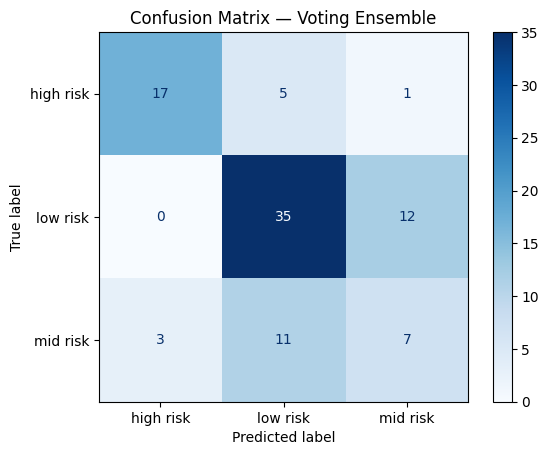

In [ ]:
for name, model in final_models.items():
    predictions = model.predict(X_test)

    print(f"\n{name}")
    print(classification_report(y_test, predictions))

    ConfusionMatrixDisplay.from_predictions(y_test, predictions, cmap = "Blues")
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

## Class-Level Performance

The Random Forest performed well for low-risk and high-risk patients:

- High risk: recall = 0.70 and F1-score = 0.76
- Low risk: recall = 0.83 and F1-score = 0.74
- Mid risk: recall = 0.29 and F1-score = 0.35

The mid-risk class was the most difficult to identify, likely because its measurements overlap with both low- and high-risk patterns. In a real triage setting, missed high-risk cases are particularly serious because they may delay referral or treatment.

In [106]:
best_name = "Random Forest (Bagging)"
best_model = final_models[best_name]

print("Model used for explainability:", best_name)

Model used for explainability: Random Forest (Bagging)


,Feature,Importance Mean,Importance Std
3,BS,0.099596,0.032902
1,SystolicBP,0.054053,0.027514
6,Pulse Pressure,0.040978,0.028205
7,MAP,0.020074,0.018772
4,BodyTemp,0.019413,0.024681
2,DiastolicBP,-0.010501,0.019523
0,Age,-0.013464,0.021808
9,HighBS_flag,-0.025621,0.020453
5,HeartRate,-0.029910,0.014190
8,AgeBand,-0.033095,0.024332


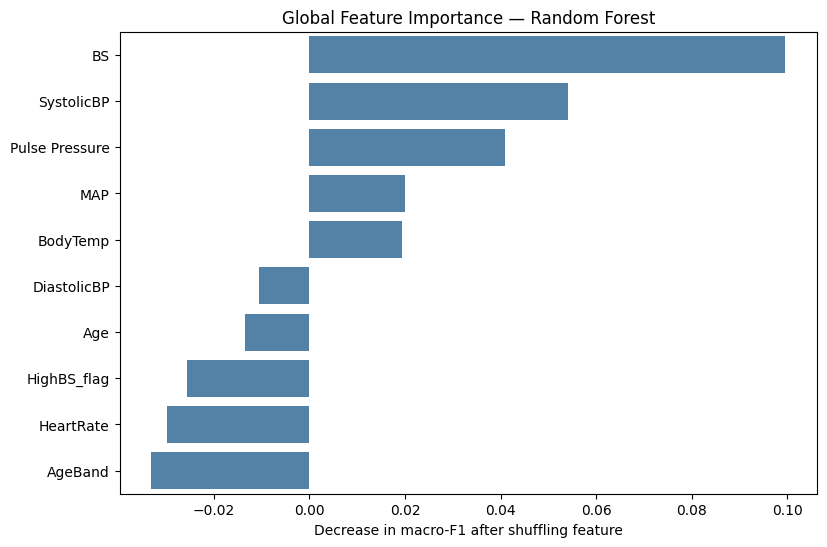

In [109]:
permutation_results = permutation_importance(
    estimator=best_model,
    X=X_test,
    y=y_test,
    scoring="f1_macro",
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

global_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": permutation_results.importances_mean,
    "Importance Std": permutation_results.importances_std
}).sort_values("Importance Mean", ascending=False)

display(global_importance)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=global_importance,
    x="Importance Mean",
    y="Feature",
    color="steelblue"
)
plt.title("Global Feature Importance — Random Forest")
plt.xlabel("Decrease in macro-F1 after shuffling feature")
plt.ylabel("")
plt.show()

## Global Model Explanation

Permutation importance identified blood sugar (`BS`) as the strongest global feature, followed by systolic blood pressure, Pulse Pressure, MAP, and body temperature.

This indicates that shuffling blood sugar caused the largest reduction in model macro-F1. The result is clinically plausible because abnormal glucose and blood-pressure values may be associated with maternal-health risk.

Negative or near-zero importance scores should not be interpreted as protective effects. Some features are correlated or derived from one another: for example, MAP and Pulse Pressure are calculated from blood-pressure values, while `HighBS_flag` is derived from blood sugar. Such redundancy can make individual importance values unstable.

In [110]:
def create_patient(age, systolic_bp, diastolic_bp, blood_sugar, body_temp, heart_rate):
    pulse_pressure = systolic_bp - diastolic_bp
    map_value = diastolic_bp + pulse_pressure / 3

    if age < 18:
        age_band_value = "teen"
    elif age < 35:
        age_band_value = "prime"
    else:
        age_band_value = "advanced"

    return pd.DataFrame([{
        "Age": age,
        "SystolicBP": systolic_bp,
        "DiastolicBP": diastolic_bp,
        "BS": blood_sugar,
        "BodyTemp": body_temp,
        "HeartRate": heart_rate,
        "Pulse Pressure": pulse_pressure,
        "MAP": map_value,
        "AgeBand": age_band_value,
        "HighBS_flag": int(blood_sugar >= 7.8)
    }])

synthetic_patient = create_patient(
    age=30,
    systolic_bp=145,
    diastolic_bp=95,
    blood_sugar=9.5,
    body_temp=99.0,
    heart_rate=88
)

display(synthetic_patient)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,Pulse Pressure,MAP,AgeBand,HighBS_flag
0,30,145,95,9.5,99.0,88,50,111.666667,prime,1


In [111]:
patient_prediction = best_model.predict(synthetic_patient)[0]
patient_probabilities = best_model.predict_proba(synthetic_patient)[0]

probability_table = pd.DataFrame({
    "Risk Level": best_model.classes_,
    "Probability": patient_probabilities
}).sort_values("Probability", ascending=False)

display(probability_table)

confidence = probability_table.iloc[0]["Probability"]

print("Predicted risk level:", patient_prediction)
print("Prediction confidence:", round(confidence, 3))

if confidence < 0.60:
    print("Low confidence: clinician review is required.")
else:
    print("Higher confidence: still requires clinician review.")

,Risk Level,Probability
0,high risk,0.913576
2,mid risk,0.079481
1,low risk,0.006942


Predicted risk level: high risk
Prediction confidence: 0.914
Higher confidence: still requires clinician review.


## Live Synthetic Prediction

A synthetic patient record was used for the live demonstration to avoid using real personal health data. The Random Forest predicted **high risk** with a confidence of **0.914**.

This prediction is for demonstration only. Model confidence is not clinical certainty, and a qualified clinician must review all predictions before any care or referral decision.

In [112]:
feature_names = list(X_train_val.columns)

ageband_to_number = {
    "advanced": 0,
    "prime": 1,
    "teen": 2
}

number_to_ageband = {
    0: "advanced",
    1: "prime",
    2: "teen"
}

lime_training_data = X_train_val.copy()
lime_training_data["AgeBand"] = lime_training_data["AgeBand"].map(ageband_to_number)

lime_patient = synthetic_patient.copy()
lime_patient["AgeBand"] = lime_patient["AgeBand"].map(ageband_to_number)

ageband_index = feature_names.index("AgeBand")
highbs_index = feature_names.index("HighBS_flag")

lime_explainer = LimeTabularExplainer(
    training_data=lime_training_data.to_numpy(dtype=float),
    feature_names=feature_names,
    class_names=list(best_model.classes_),
    categorical_features=[ageband_index, highbs_index],
    categorical_names={
        ageband_index: ["advanced", "prime", "teen"],
        highbs_index: ["No", "Yes"]
    },
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

def lime_predict_proba(lime_array):
    lime_dataframe = pd.DataFrame(lime_array, columns=feature_names)

    lime_dataframe["AgeBand"] = (
        lime_dataframe["AgeBand"]
        .round()
        .astype(int)
        .map(number_to_ageband)
    )

    lime_dataframe["HighBS_flag"] = (
        lime_dataframe["HighBS_flag"]
        .round()
        .astype(int)
    )

    return best_model.predict_proba(lime_dataframe)

Local explanation for predicted class: high risk
BS > 7.90: increased the predicted probability (0.380)
SystolicBP > 120.00: increased the predicted probability (0.242)
BodyTemp > 98.00: increased the predicted probability (0.119)
HighBS_flag=Yes: increased the predicted probability (0.100)
MAP > 96.67: increased the predicted probability (0.086)
HeartRate > 80.00: increased the predicted probability (0.031)
AgeBand=prime: decreased the predicted probability (-0.022)
DiastolicBP > 85.00: increased the predicted probability (0.017)
Pulse Pressure > 40.00: increased the predicted probability (0.010)
25.00 < Age <= 37.25: increased the predicted probability (0.008)


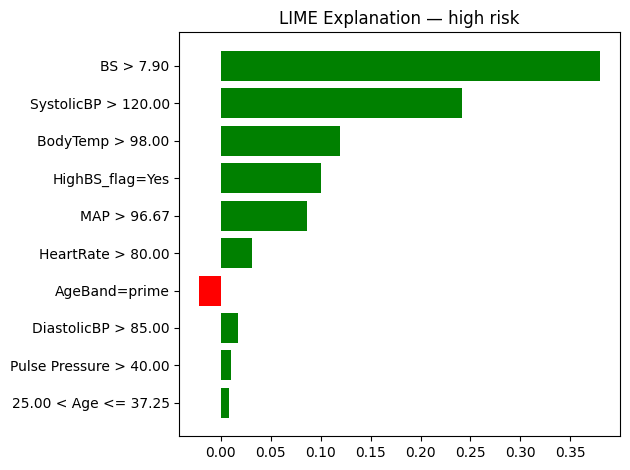

In [113]:
predicted_class_index = list(best_model.classes_).index(patient_prediction)

lime_explanation = lime_explainer.explain_instance(
    data_row=lime_patient.to_numpy(dtype=float)[0],
    predict_fn=lime_predict_proba,
    labels=[predicted_class_index],
    num_features=10
)

print(f"Local explanation for predicted class: {patient_prediction}")

for feature, contribution in lime_explanation.as_list(
    label=predicted_class_index
):
    direction = "increased" if contribution > 0 else "decreased"
    print(
        f"{feature}: {direction} the predicted probability "
        f"({contribution:.3f})"
    )

figure = lime_explanation.as_pyplot_figure(
    label=predicted_class_index
)
plt.title(f"LIME Explanation — {patient_prediction}")
plt.tight_layout()
plt.show()

## Individual Prediction Explanation

For the synthetic patient, LIME showed that elevated blood sugar was the largest contributor to the high-risk prediction. Elevated systolic blood pressure, body temperature, `HighBS_flag`, and MAP also increased the predicted probability of high risk.

These results are consistent with the global importance analysis. However, LIME explains the behaviour of this model for this one record only; it does not establish medical causation and must not be treated as a diagnosis.

In [114]:
fairness_data = X_test[["AgeBand"]].copy()
fairness_data["Actual"] = y_test
fairness_data["Predicted"] = best_model.predict(X_test)

fairness_rows = []

for age_band_name, group in fairness_data.groupby("AgeBand"):
    actual_high_risk = group["Actual"] == "high risk"
    predicted_high_risk = group["Predicted"] == "high risk"

    fairness_rows.append({
        "Age Band": age_band_name,
        "Sample Size": len(group),
        "Macro F1": f1_score(
            group["Actual"],
            group["Predicted"],
            labels=best_model.classes_,
            average="macro",
            zero_division=0
        ),
        "High-Risk Recall": recall_score(
            actual_high_risk,
            predicted_high_risk,
            zero_division=0
        ),
        "High-Risk Precision": precision_score(
            actual_high_risk,
            predicted_high_risk,
            zero_division=0
        )
    })

fairness_results = pd.DataFrame(fairness_rows)

fairness_results

,Age Band,Sample Size,Macro F1,High-Risk Recall,High-Risk Precision
0,advanced,25,0.538647,0.769231,0.909091
1,prime,43,0.672883,0.714286,1.000000
2,teen,23,0.421744,0.333333,0.333333


## Fairness Assessment

Performance varied across age bands:

| Age Band | Macro-F1 | High-Risk Recall |
|---|---:|---:|
| Advanced | 0.539 | 0.769 |
| Prime | 0.673 | 0.714 |
| Teen | 0.422 | 0.333 |

The teen group had the weakest performance and the lowest high-risk recall. This means the model missed more high-risk teen cases than high-risk cases in the other age bands.

The subgroup samples are small, and the dataset lacks other important demographic variables. Therefore, these results do not prove fairness. They instead show that more data, subgroup validation, and clinician oversight would be required before deployment.

## Ethics and Deployment Limitations

This system is intended only as a maternal-health triage and decision-support tool. It must not replace clinical diagnosis, treatment, or referral decisions.

False negatives are the most serious error because predicting a high-risk patient as low or mid risk may delay urgent care. False positives can cause anxiety, unnecessary testing, and additional pressure on limited health services.

The dataset is small and may not represent all maternal populations, locations, clinical practices, or measurement devices. It has not been externally validated, prospectively tested, clinically approved, or assessed for all protected groups.

Any real-world deployment would require de-identified data, secure storage, access controls, continuous monitoring, external validation, clinician-approved thresholds, and qualified human oversight for every prediction.